In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_student_data
from src.preprocessing import (
    create_target,
    create_features_and_target,
    build_preprocessor
)
from src.baseline import build_baseline

In [2]:
df = load_student_data()

print("Dataset shape:", df.shape)

Dataset shape: (395, 33)


In [3]:
df = create_target(df)

df[["G3", "performance_class"]].head(10)

,G3,performance_class
0,6,Low
1,6,Low
2,10,Medium
3,15,High
4,10,Medium
5,15,High
6,11,Medium
7,6,Low
8,19,High
9,15,High


In [5]:
class_counts = df["performance_class"].value_counts()

print(class_counts)

class_percentages = (
    df["performance_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

performance_class
Medium    192
Low       130
High       73
Name: count, dtype: int64
performance_class
Medium    48.61
Low       32.91
High      18.48
Name: proportion, dtype: float64


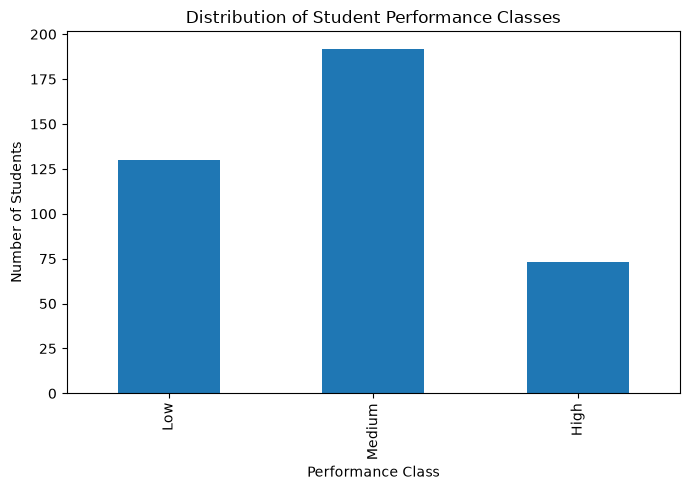

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df["performance_class"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Class")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "performance_class_distribution.png",
    dpi=300
)

plt.show()

In [8]:
X, y = create_features_and_target(df)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (395, 32)
y shape: (395,)
Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Target:
performance_class


In [9]:
if "G3" in X.columns:
    raise ValueError("Target leakage detected: G3 is in X.")

if "performance_class" in X.columns:
    raise ValueError(
        "Target leakage detected: performance_class is in X."
    )

print("No target leakage detected.")

No target leakage detected.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 316
Testing samples: 79

Training class distribution:
performance_class
Medium    0.487
Low       0.329
High      0.184
Name: proportion, dtype: float64

Testing class distribution:
performance_class
Medium    0.481
Low       0.329
High      0.190
Name: proportion, dtype: float64


In [13]:
preprocessor = build_preprocessor()

print(preprocessor)

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'Medu', 'Fedu', 'traveltime',
                                  'studytime', 'failures', 'famrel', 'freetime',
                                  'goout', 'Dalc', 'Walc', 'health', 'absences',
                                  'G1', 'G2']),
                                ('categorical',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                  'romantic'])])


In [14]:
baseline = build_baseline(preprocessor)

print(baseline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health', 'absences',
                                                   'G1', 'G2']),
                                                 ('categorical',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                   

In [15]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['age','Medu','Fedu',...,'higher','internet','romantic']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [16]:
y_pred_baseline = baseline.predict(X_test)

In [17]:
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print(
    f"Baseline accuracy: "
    f"{baseline_accuracy:.4f}"
)

Baseline accuracy: 0.4810


In [18]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.00      0.00      0.00        15
         Low       0.00      0.00      0.00        26
      Medium       0.48      1.00      0.65        38

    accuracy                           0.48        79
   macro avg       0.16      0.33      0.22        79
weighted avg       0.23      0.48      0.31        79



In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

print(cm)

[[ 0  0 15]
 [ 0  0 26]
 [ 0  0 38]]


In [22]:
baseline_results = pd.DataFrame({
    "Model": ["DummyClassifier"],
    "Accuracy": [baseline_accuracy]
})

baseline_results.to_csv(
    PROJECT_ROOT / "results" / "baseline_results.csv",
    index=False
)

baseline_results

,Model,Accuracy
0,DummyClassifier,0.481013
